In [59]:
import geopandas as gpd 
import pandas as pd 
import matplotlib.pyplot as plt
from  datetime import datetime
import numpy as np 

In [ ]:
data = gpd.read_file(r"C:\FATE\Palmyra FAD Watch GIS data for NASA (Nov 2024)-selected\MI_and_SAT_FAD_positions")
data.shape ##Checking if the files were combined correctly

(2435, 17)

C:\Users\czerfass\AppData\Local\Temp\3\ipykernel_17864\4305533.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


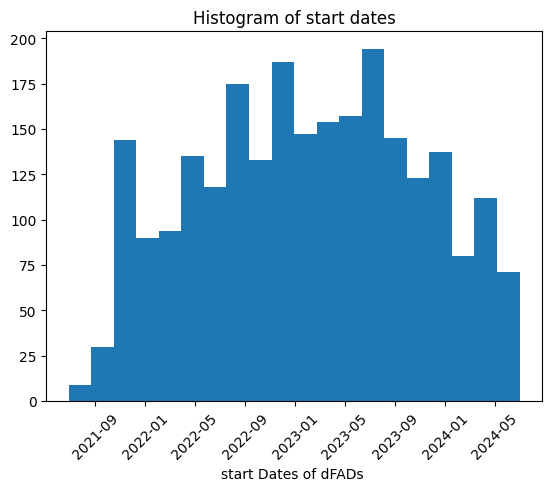

In [21]:
fig, ax = plt.subplots()
ax.hist(data['MinOfDate'], bins = 20)
ax.tick_params(axis='x', labelrotation=45)
ax.set_xlabel("start Dates of dFADs ")
ax.set_title("Histogram of start dates")
fig.show()

Filter through to find when the most amount of dFads come into the geotracked area. 
    has to be two even years
    has to be by month

In [ ]:
shorten = data.query('MinOfDate > 2022' )
shorten = shorten.query('MinOfDate < 2024')
print(shorten['MinOfDate'].min())
print(shorten['MinOfDate'].max()) 
##only includes from two years so propery weighted
shorten["Month"] = shorten['MinOfDate'].dt.strftime("%m") ## removes year
print(shorten['Month'].head(5))
shorten['Month'] = shorten['Month'].sort_values()
sorted_counts = shorten['Month'].value_counts().sort_index()


2022-01-02 00:00:00
2023-12-31 00:00:00
0    05
2    02
5    06
6    08
8    01
Name: Month, dtype: object


C:\Users\czerfass\AppData\Local\Temp\3\ipykernel_17864\1065029139.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


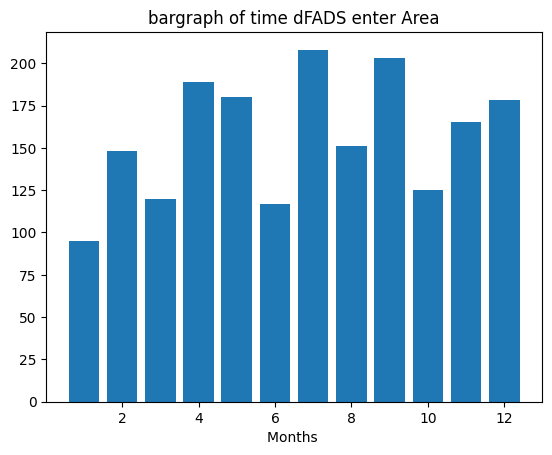

In [64]:
fig, ax = plt.subplots()
line = np.linspace(1,12,12)
ax.bar(line, sorted_counts)
ax.set_xlabel("Months ")
ax.set_title("bargraph of time dFADS enter Area")
fig.show()